# Bài tập: Phân loại Spam Email bằng Logistic Regression
* **Họ tên:** [Điền họ tên của bạn]
* **MSSV:** [Điền MSSV của bạn]


## 1. Thiết lập môi trường và Import thư viện


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')


## 2. Tải và Khám phá dữ liệu (EDA)


--- 5 DÒNG ĐẦU DỮ LIỆU ---


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0



--- THÔNG TIN DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  5171 non-null   int64
 1   label       5171 non-null   str  
 2   text        5171 non-null   str  
 3   label_num   5171 non-null   int64
dtypes: int64(2), str(2)
memory usage: 161.7 KB

--- THỐNG KÊ CHI TIẾT NHÃN ---
Số lượng:
label
ham     3672
spam    1499
Name: count, dtype: int64

Tỉ lệ phần trăm:
label
ham     71.01141
spam    28.98859
Name: proportion, dtype: float64


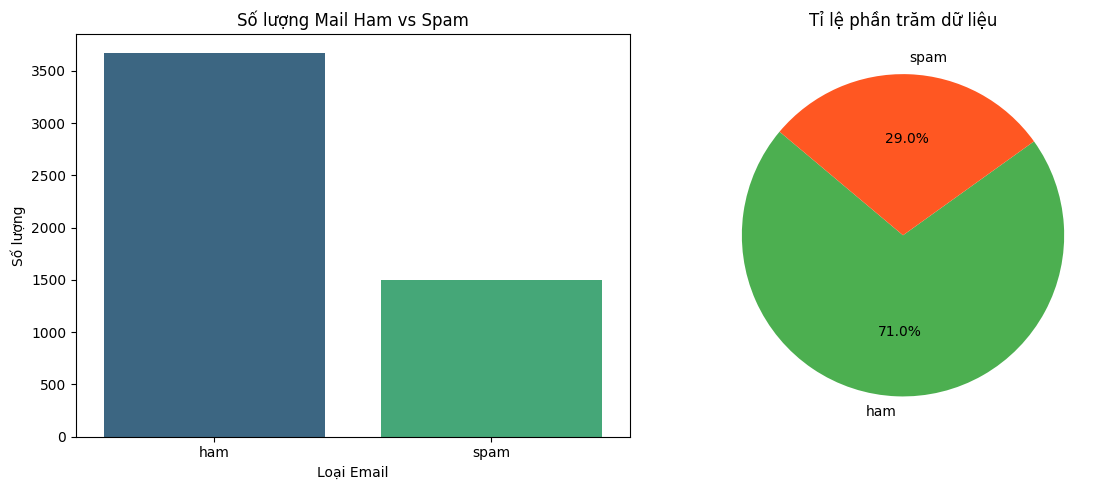

In [2]:
# Tải tập dữ liệu từ file local CSV
df = pd.read_csv('spam_ham_dataset.csv')

# Xem 5 dòng đầu
print('--- 5 DÒNG ĐẦU DỮ LIỆU ---')
display(df.head())

# Thông tin dữ liệu
print('\n--- THÔNG TIN DỮ LIỆU ---')
df.info()

# Thống kê nhãn
counts = df['label'].value_counts()
percent = df['label'].value_counts(normalize=True) * 100
print('\n--- THỐNG KÊ CHI TIẾT NHÃN ---')
print(f'Số lượng:\n{counts}')
print(f'\nTỉ lệ phần trăm:\n{percent}')

# Vẽ biểu đồ phân bố nhãn
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Số lượng Mail Ham vs Spam')
plt.xlabel('Loại Email')
plt.ylabel('Số lượng')

plt.subplot(1, 2, 2)
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=['#4CAF50', '#FF5722'])
plt.title('Tỉ lệ phần trăm dữ liệu')
plt.tight_layout()
plt.show()


## 3. Tiền xử lý dữ liệu (Preprocessing)


In [3]:
# Xóa bỏ dữ liệu trống nếu có
df = df.dropna()

# Ánh xạ nhãn: spam -> 1, ham -> 0
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

# Tách tập Test gốc (20%) độc lập trước để kiểm thử
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Xử lý mất cân bằng tập huấn luyện: Downsampling tập Train để chỉ có 35% Spam
df_spam_train = df_train_full[df_train_full['label_num'] == 1]
df_ham_train = df_train_full[df_train_full['label_num'] == 0]

n_spam = len(df_spam_train)
n_ham_needed = int((n_spam / 0.35) - n_spam)
df_ham_train_downsampled = df_ham_train.sample(n=min(n_ham_needed, len(df_ham_train)), random_state=42)

# Gộp lại thành tập huấn luyện chính thức
df_train_final = pd.concat([df_spam_train, df_ham_train_downsampled]).sample(frac=1, random_state=42)

X_train_raw = df_train_final['text'].astype(str).values
y_train = df_train_final['label_num'].values

# Vector hóa văn bản tập huấn luyện
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(X_train_raw).toarray()
print(f'Kích thước dữ liệu huấn luyện sau vector hóa: {X_train.shape}')


Kích thước dữ liệu huấn luyện sau vector hóa: (3445, 5000)


## 4. Xây dựng và Huấn luyện mô hình


Vòng lặp 0...
Vòng lặp 500...
Vòng lặp 1000...
Vòng lặp 1500...
Vòng lặp 2000...
Vòng lặp 2500...
Huấn luyện hoàn thành!


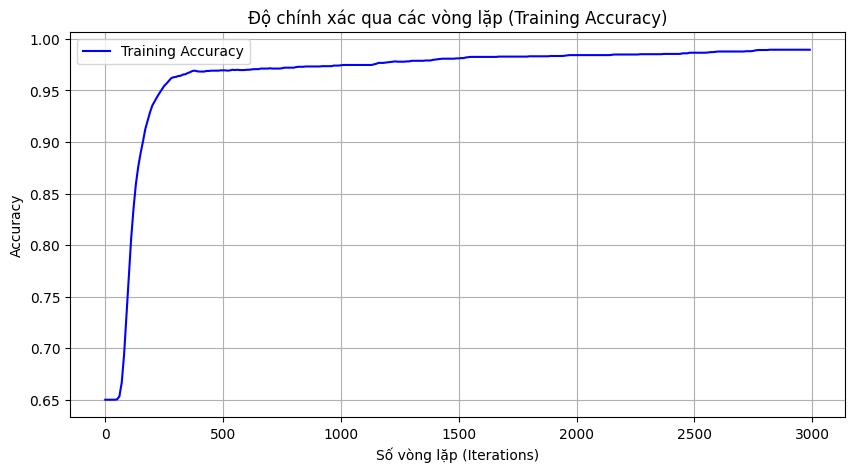

Đã lưu mô hình thành công tại: logistic_custom_model.pkl


In [4]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.5, iterations=2000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.history = []

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        return [1 if i > 0.5 else 0 for i in y_predicted]

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if i % 10 == 0:
                y_pred_labels = [1 if p > 0.5 else 0 for p in y_predicted]
                acc = np.mean(y_pred_labels == y)
                self.history.append(acc)

            if i % 500 == 0:
                print(f'Vòng lặp {i}...')

# Khởi tạo và huấn luyện mô hình
model = LogisticRegressionScratch(learning_rate=1.0, iterations=3000)
model.fit(X_train, y_train)
print('Huấn luyện hoàn thành!')

# Vẽ biểu đồ độ chính xác qua các vòng lặp
plt.figure(figsize=(10, 5))
plt.plot(range(0, len(model.history) * 10, 10), model.history, color='blue', label='Training Accuracy')
plt.title('Độ chính xác qua các vòng lặp (Training Accuracy)')
plt.xlabel('Số vòng lặp (Iterations)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# Lưu mô hình
model_data = {
    'weights': model.weights,
    'bias': model.bias,
    'vocabulary': vectorizer.vocabulary_,
    'idf': vectorizer.idf_
}
filename = 'logistic_custom_model.pkl'
with open(filename, 'wb') as f:
    pickle.dump(model_data, f)
print(f'Đã lưu mô hình thành công tại: {filename}')


## 5. Dự đoán và Đánh giá kết quả


Độ chính xác (Accuracy) trên tập Test: 98.07%

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99       742
        Spam       0.95      0.99      0.97       293

    accuracy                           0.98      1035
   macro avg       0.97      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035



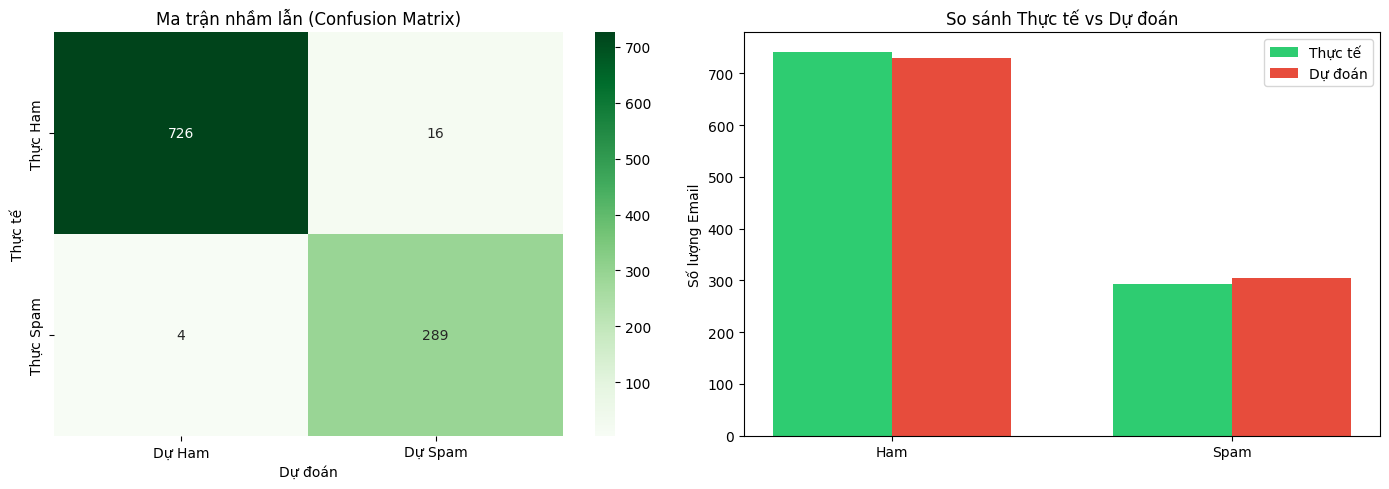

In [5]:
# 1. ĐƯỜNG DẪN
PATH_MODEL_PKL = 'logistic_custom_model.pkl'
PATH_DATA_CSV = 'spam_ham_dataset.csv'

# 2. TẢI MÔ HÌNH VÀ TÁCH TẬP TEST GỐC
with open(PATH_MODEL_PKL, 'rb') as f:
    model_data = pickle.load(f)

weights = model_data['weights']
bias = model_data['bias']
vocab = model_data['vocabulary']
saved_idf = model_data['idf']

df = pd.read_csv(PATH_DATA_CSV)
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})
X_text = df['text'].astype(str).values
y = df['label_num'].values

# Sử dụng random_state=42 khớp hoàn chỉnh
_, X_test_raw, _, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# 3. VECTOR HÓA VÀ DỰ ĐOÁN THỦ CÔNG
vectorizer = TfidfVectorizer(vocabulary=vocab)
vectorizer.idf_ = saved_idf
X_test = vectorizer.transform(X_test_raw).toarray()

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def predict(X, w, b):
    linear_model = np.dot(X, w) + b
    y_prob = sigmoid(linear_model)
    return np.array([1 if i > 0.5 else 0 for i in y_prob])

y_pred = predict(X_test, weights, bias)

# 4. ĐÁNH GIÁ VÀ VẼ BIỂU ĐỒ KẾT QUẢ
acc = accuracy_score(y_test, y_pred)
print('='*50)
print(f'Độ chính xác (Accuracy) trên tập Test: {acc*100:.2f}%')
print('='*50)
print('\nBáo cáo phân loại chi tiết (Classification Report):')
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

plt.figure(figsize=(14, 5))
# Subplot 1: Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dự Ham', 'Dự Spam'],
            yticklabels=['Thực Ham', 'Thực Spam'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')

# Subplot 2: So sánh số lượng thực tế vs dự đoán
plt.subplot(1, 2, 2)
labels = ['Ham', 'Spam']
actual_counts = [np.sum(y_test == 0), np.sum(y_test == 1)]
pred_counts = [np.sum(y_pred == 0), np.sum(y_pred == 1)]

x = np.arange(len(labels))
width = 0.35
plt.bar(x - width/2, actual_counts, width, label='Thực tế', color='#2ecc71')
plt.bar(x + width/2, pred_counts, width, label='Dự đoán', color='#e74c3c')
plt.ylabel('Số lượng Email')
plt.title('So sánh Thực tế vs Dự đoán')
plt.xticks(x, labels)
plt.legend()
plt.tight_layout()
plt.show()


### Thử nghiệm dự đoán trên văn bản email mới


In [6]:
new_emails = [
    "Congratulations! You've won a free iPhone. Click here to claim your prize!",
    "We detected a new sign-in attempt to your account. Please confirm your identity below if this wasn't you."
]

print('--- DỰ ĐOÁN TRÊN VĂN BẢN TÙY Ý ---')
for text in new_emails:
    X_new = vectorizer.transform([text]).toarray()
    pred = predict(X_new, weights, bias)
    result = 'Spam' if pred[0] == 1 else 'Ham'
    print(f'Văn bản: "{text}"')
    print(f'-> Dự đoán: {result}\n')


--- DỰ ĐOÁN TRÊN VĂN BẢN TÙY Ý ---
Văn bản: "Congratulations! You've won a free iPhone. Click here to claim your prize!"
-> Dự đoán: Spam

Văn bản: "We detected a new sign-in attempt to your account. Please confirm your identity below if this wasn't you."
-> Dự đoán: Spam

